# Lab 03 · MRI DICOM and NIfTI Analysis
**Lý Chính Tân · HCMUT · Medical Imaging coursework**

Load an explicitly selected MRI sequence, inspect spatial metadata, visualize volumes and slices,
compare matched representations in physical coordinates, and examine a JPEG display export.
This is structural MRI visualization. A 3D anatomical image does not establish an fMRI analysis.

**Theory:** T1 contrast depends on longitudinal recovery; T2 contrast depends on transverse decay.
FLAIR uses inversion recovery to suppress CSF. DICOM and NIfTI are storage formats, not pulse sequences;
the format alone does not determine spatial resolution, contrast or diagnostic quality.

## 1. Configuration

In [1]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the repository root or notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'imaging_labs').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook inside the medical-imaging-labs repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from imaging_labs.common import normalize_display, image_metrics, show_images, save_figure

# Choose 'demo' or 'local'. Local mode never falls back silently to demo data.
MODE = os.environ.get('IMAGING_LABS_MODE', 'demo')
DATA_ROOT = Path(os.environ.get('IMAGING_LABS_DATA', str(ROOT / 'data')))
OUTPUT_ROOT = Path(os.environ.get('IMAGING_LABS_OUTPUT', str(ROOT / 'results'))) / MODE
if MODE not in {'demo', 'local'}:
    raise ValueError("MODE must be 'demo' or 'local'")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
print('Input mode:', MODE)

Input mode: demo


In [2]:
from imaging_labs.mri import (load_dicom_series, load_nifti, spatial_summary,
                              canonical_data, compare_volumes, slice_quality, slice_viewer)
from imaging_labs.demo import write_mri_demo
from PIL import Image

OUTPUT = OUTPUT_ROOT / 'mri'
OUTPUT.mkdir(parents=True, exist_ok=True)
SEQUENCE = 'T1'  # T1, T2 or FLAIR; select the matching DICOM and NIfTI explicitly.
MRI_ROOT = DATA_ROOT / 'mri' / 'Neurohacking_data-0.0' / 'BRAINIX'
TIME_INDEX = None  # Set explicitly when supplying a 4D NIfTI time series.
ENABLE_WIDGETS = os.environ.get('IMAGING_LABS_WIDGETS', '1') == '1'

## 2. Load a matched sequence
Local mode uses `DICOM/<SEQUENCE>` and `NIfTI/BRAINIX_NIFTI_<SEQUENCE>.nii.gz`.
The loader sorts DICOM slices along their physical slice normal and applies per-slice rescaling.
It validates series identity, consistent orientation, pixel spacing and regular slice positions.
It supports conventional single-frame MONOCHROME2 series; unsupported geometry produces an explicit error.
No patient identifiers are printed or exported by this notebook.

In [3]:
if MODE == 'demo':
    paths = write_mri_demo(OUTPUT / 'synthetic_inputs')
    dicom_path, nifti_path = paths['dicom'], paths['nifti']
    same_acquisition = True  # Both files were generated from the same synthetic volume.
else:
    dicom_path = MRI_ROOT / 'DICOM' / SEQUENCE
    nifti_path = MRI_ROOT / 'NIfTI' / f'BRAINIX_NIFTI_{SEQUENCE}.nii.gz'
    same_acquisition = True  # Paired BRAINIX sequence supplied with the coursework.
    # For other data, establish acquisition identity; matching filenames alone are insufficient.
dicom_image = load_dicom_series(dicom_path)
nifti_image = load_nifti(nifti_path, time_index=TIME_INDEX)
display(pd.DataFrame([{'format': 'DICOM', **spatial_summary(dicom_image)},
                      {'format': 'NIfTI', **spatial_summary(nifti_image)}]))

,format,shape,voxel_spacing_mm,voxel_axis_codes,obliquity_deg
0,DICOM,"(40, 44, 12)","(1.1, 0.9, 2.5)",PLS,"(0.0, 0.0, 0.0)"
1,NIfTI,"(40, 44, 12)","(1.100000023841858, 0.8999999761581421, 2.5)",PLS,"(0.0, 0.0, 0.0)"


## 3. Three orthogonal voxel-grid views and slice montage
NIfTI affine metadata describes voxel-to-world coordinates. Canonicalization reorders/flips axes toward
RAS+ without interpolation. It does not remove acquisition obliquity: the views below are sections along
canonical voxel axes and may be oblique to true anatomical planes.

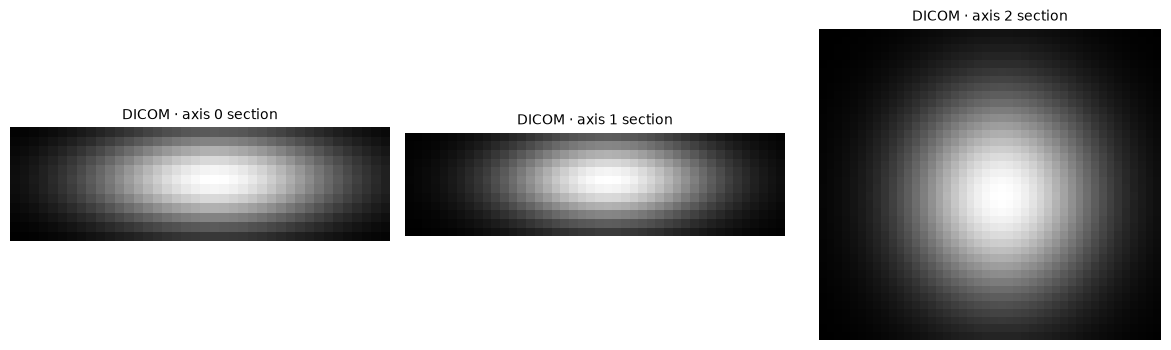

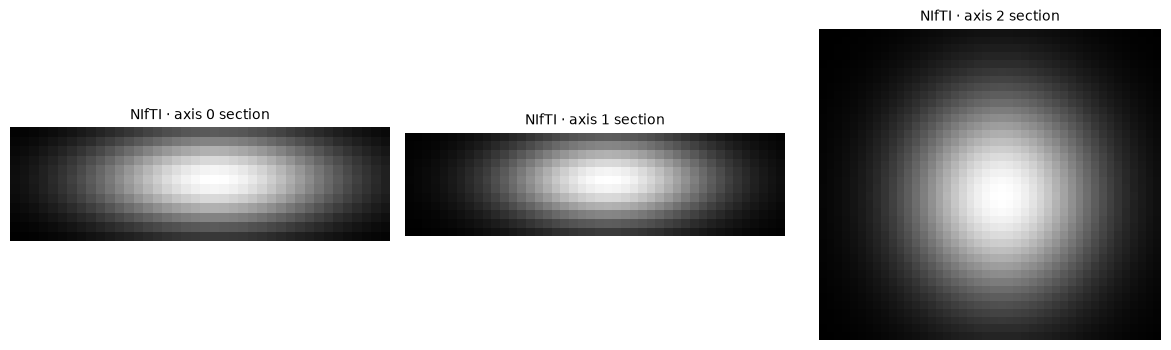

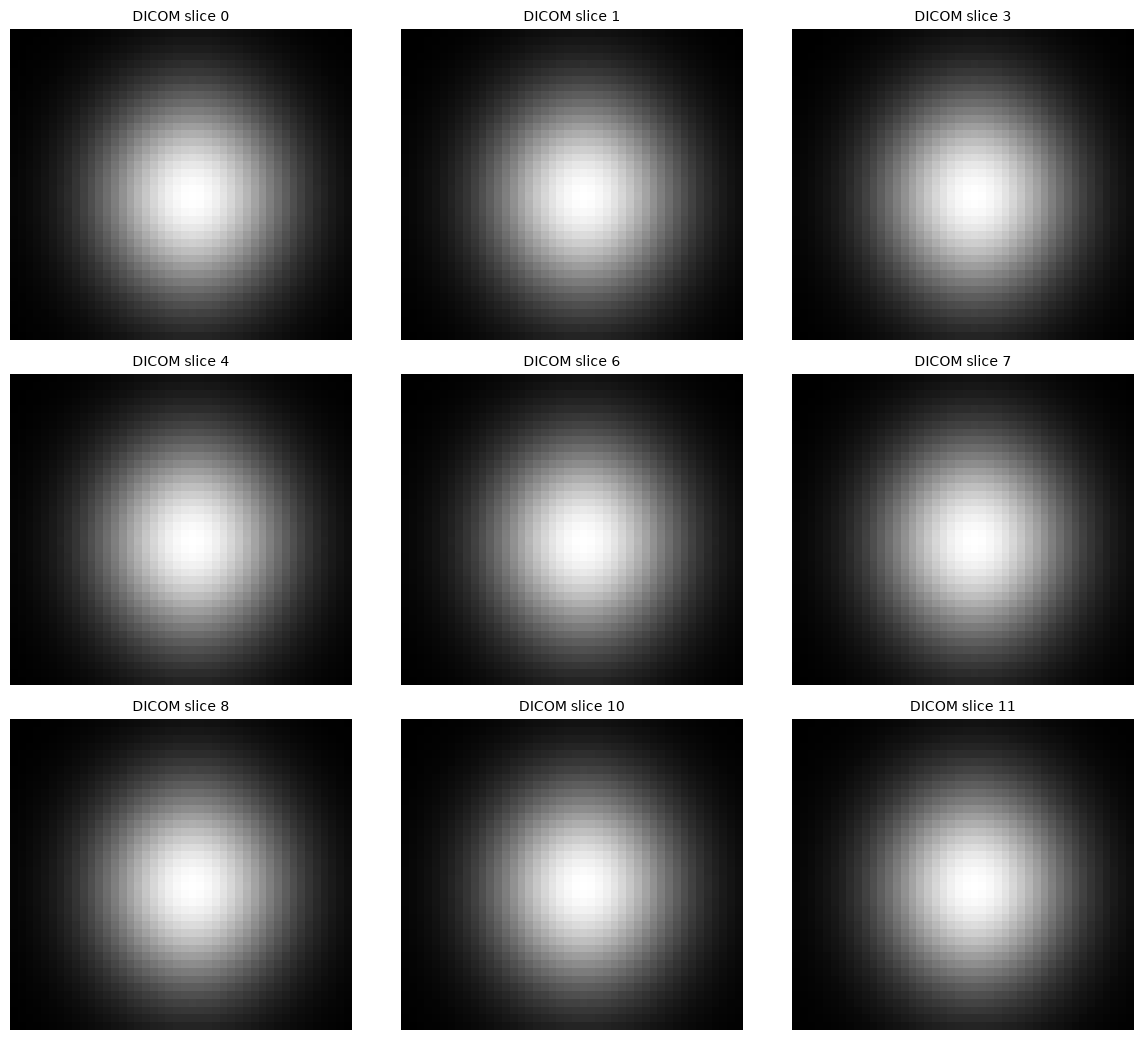

In [4]:
dicom_data, nifti_data = canonical_data(dicom_image), canonical_data(nifti_image)
for label, volume in [('DICOM', dicom_data), ('NIfTI', nifti_data)]:
    center = np.array(volume.shape)//2
    planes = [volume[center[0], :, :].T, volume[:, center[1], :].T, volume[:, :, center[2]].T]
    fig = show_images(planes, [label+' · axis 0 section', label+' · axis 1 section', label+' · axis 2 section'])
    save_figure(fig, OUTPUT, label.lower()+'_three_views.png')
    plt.show()
indices = np.unique(np.linspace(0, dicom_data.shape[2]-1, 9).round().astype(int))
fig = show_images([dicom_data[:, :, i].T for i in indices], [f'DICOM slice {i}' for i in indices])
save_figure(fig, OUTPUT, 'dicom_montage.png')
plt.show()

## 4. Interactive slice viewing
Both sliders operate independently on native canonical voxel grids. An optional interpolated slider
provides smoother browsing only; it creates no new acquired resolution and is not used for metrics.

In [5]:
if ENABLE_WIDGETS:
    display(slice_viewer(dicom_image, 'DICOM'))
    display(slice_viewer(nifti_image, 'NIfTI'))
    display(slice_viewer(dicom_image, 'DICOM', display_slices=88))
else:
    print('Widgets disabled for batch validation; static figures remain available.')

Widgets disabled for batch validation; static figures remain available.


## 5. Compare matching representations in physical coordinates
Use orientation/affine metadata rather than proportional slice indices or searching rotations that
maximize SSIM. Exact matching canonical grids avoid resampling altogether. If grids differ, resample
the moving image onto the reference and exclude non-overlap. This does not register different patients,
sessions or motion states. Intensity scales must be compatible before interpreting errors.

,mae,rmse,reference_range,overlap_fraction
0,0.0,0.0,1000.0,1.0


,slice,mae,rmse,psnr_db,ssim
0,0,0.0,0.0,inf,1.0
1,1,0.0,0.0,inf,1.0
2,2,0.0,0.0,inf,1.0
3,3,0.0,0.0,inf,1.0
4,4,0.0,0.0,inf,1.0


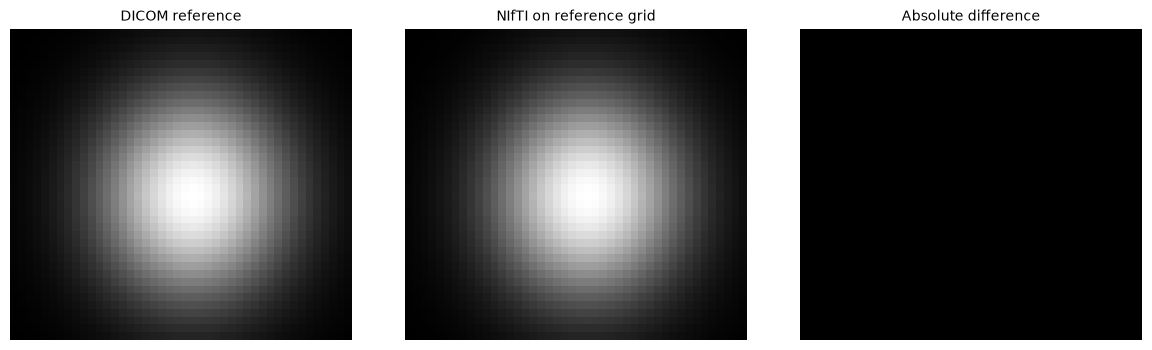

In [6]:
comparison = compare_volumes(dicom_image, nifti_image, same_acquisition=same_acquisition)
reference, aligned, valid = comparison['reference'], comparison['aligned'], comparison['valid']
volume_metrics = {k:v for k,v in comparison.items() if k not in {'reference','aligned','valid'}}
display(pd.DataFrame([volume_metrics]))
(OUTPUT/'volume_consistency.json').write_text(json.dumps(volume_metrics, indent=2), encoding='utf-8')
slice_rows = []
data_range = max(volume_metrics['reference_range'], 1e-8)
for index in range(reference.shape[2]):
    if valid[:, :, index].all():
        slice_rows.append({'slice': index, **image_metrics(reference[:, :, index], aligned[:, :, index], data_range=data_range)})
slice_metrics = pd.DataFrame(slice_rows)
display(slice_metrics.head())
slice_metrics.to_csv(OUTPUT/'slice_consistency.csv', index=False)
middle = reference.shape[2]//2
fig = show_images([reference[:, :, middle].T, aligned[:, :, middle].T,
                  np.abs(reference[:, :, middle]-aligned[:, :, middle]).T],
                 ['DICOM reference', 'NIfTI on reference grid', 'Absolute difference'])
save_figure(fig, OUTPUT, 'matched_comparison.png')
plt.show()

## 6. Descriptive image measurements
Gradient energy and Laplacian variance describe sharpness, not measured spatial resolution. Entropy
is not a universal quality score. Foreground/background masks are heuristic; the background MAD and
foreground/noise ratio are **proxies**, not calibrated MRI SNR estimates. Constant background yields
an undefined noise estimate, not infinite quality. No automatic DICOM/NIfTI winner is assigned.

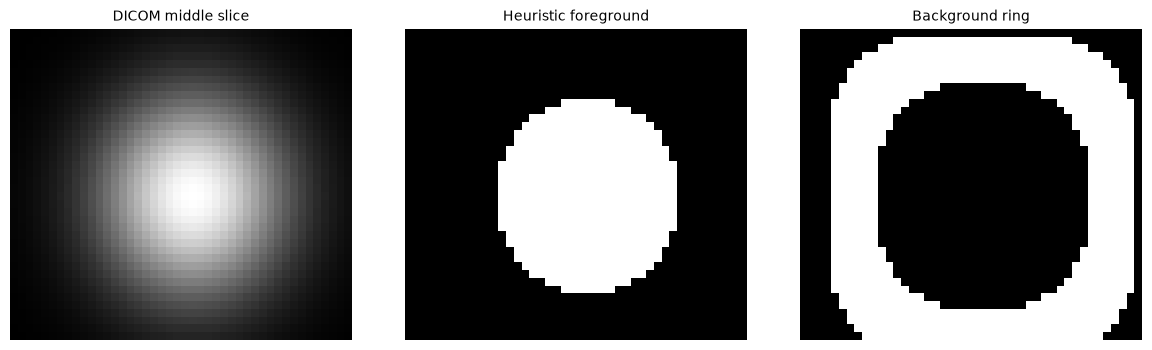

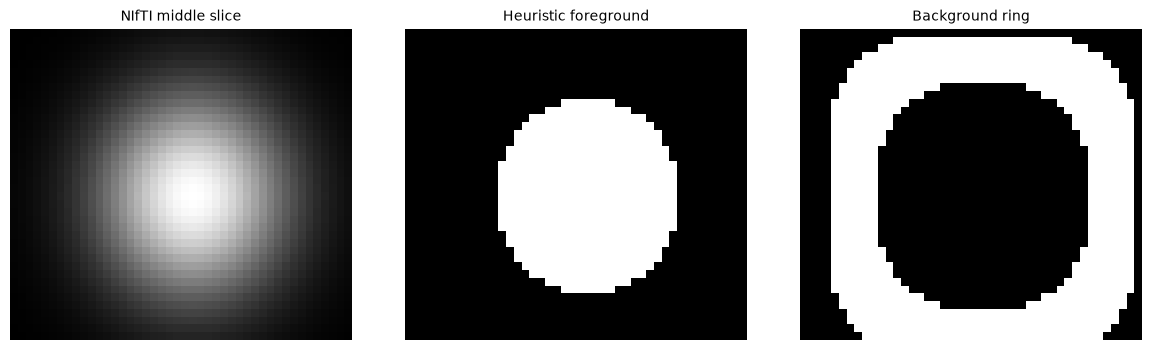

,format,slice,laplacian_variance,gradient_energy,entropy_bits,raw_p99_minus_p01,background_mad_sigma_proxy,foreground_to_noise_proxy,foreground_pixels,background_pixels
0,DICOM,6,0.000128,0.119429,7.095553,923.0,66.717,9.277963,467,766
1,NIfTI,6,0.000128,0.119429,7.095553,923.0,66.717,9.277963,467,766


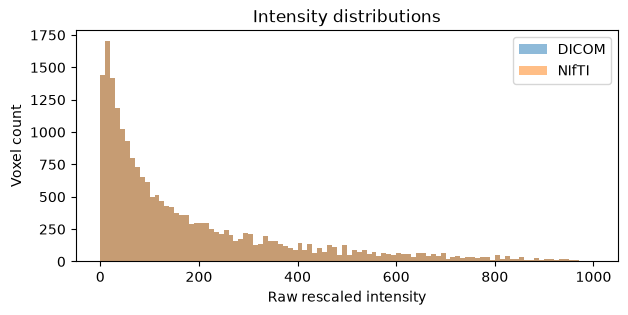

In [7]:
quality_rows = []
for label, volume in [('DICOM', dicom_data), ('NIfTI', nifti_data)]:
    index = volume.shape[2]//2
    raw_slice = volume[:, :, index]
    metrics, foreground, ring = slice_quality(raw_slice)
    quality_rows.append({'format': label, 'slice': index, **metrics})
    fig = show_images([raw_slice.T, foreground.T, ring.T],
                      [label+' middle slice', 'Heuristic foreground', 'Background ring'])
    plt.show()
quality = pd.DataFrame(quality_rows)
display(quality)
quality.to_csv(OUTPUT/'slice_quality_proxies.csv', index=False)
fig, ax = plt.subplots(figsize=(7, 3))
for label, volume in [('DICOM', dicom_data), ('NIfTI', nifti_data)]:
    ax.hist(volume.ravel(), bins=100, alpha=.5, label=label)
ax.set(xlabel='Raw rescaled intensity', ylabel='Voxel count', title='Intensity distributions')
ax.legend()
plt.show()

## 7. JPEG display export
JPEG is evaluated against the **same windowed 8-bit slice**, isolating compression loss from geometry.
The PNG is a display export too; neither restores original voxel intensities or the 3D spatial metadata.
This experiment cannot establish that a medical storage format is intrinsically better than another.

,mae,rmse,psnr_db,ssim
0,0.669886,0.945384,48.618643,0.998669


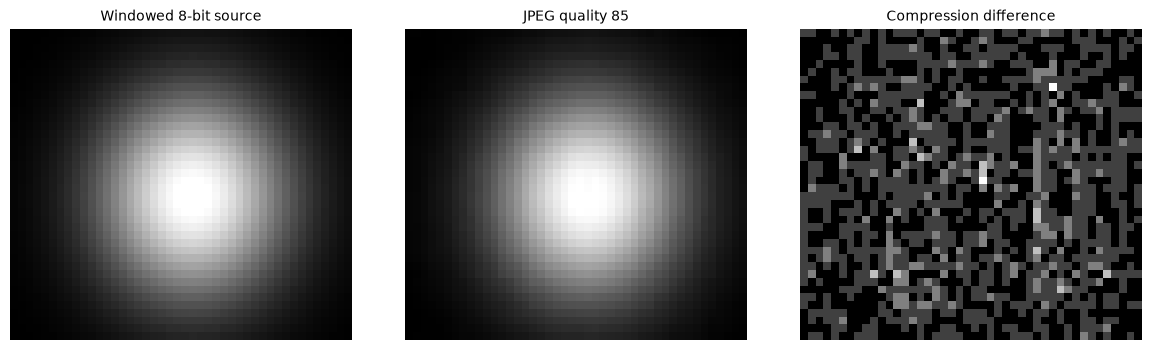

In [8]:
raw_slice = reference[:, :, middle].T
display_u8 = np.round(255*normalize_display(raw_slice)).astype('uint8')
Image.fromarray(display_u8).save(OUTPUT/'middle_slice_display.png')
jpeg_path = OUTPUT/'middle_slice_display_quality85.jpg'
Image.fromarray(display_u8).save(jpeg_path, quality=85)
jpeg = np.asarray(Image.open(jpeg_path).convert('L'))
jpeg_metrics = image_metrics(display_u8, jpeg, data_range=255)
display(pd.DataFrame([jpeg_metrics]))
pd.DataFrame([jpeg_metrics]).to_csv(OUTPUT/'jpeg_display_metrics.csv', index=False)
fig = show_images([display_u8, jpeg, np.abs(display_u8.astype(float)-jpeg)],
                 ['Windowed 8-bit source', 'JPEG quality 85', 'Compression difference'])
save_figure(fig, OUTPUT, 'jpeg_comparison.png')
plt.show()

## 8. Interpretation and reproducibility
- Spatial resolution is described by acquisition and voxel geometry, not file extension.
- DICOM and NIfTI can preserve identical voxel information despite different array orientation.
- Resampling and independent intensity normalization can introduce or hide differences.
- A slider with more slices does not create additional acquired detail.
- A 4D NIfTI can hold time points; temporal/fMRI inference would require an appropriate dataset and separate analysis.

**References:** supplied Lab 3 MRI handout, Le Nhat Tan, HCMUT;
[NiBabel DICOM geometry](https://nipy.org/nibabel/dicom/dicom_orientation.html),
[coordinate systems](https://nipy.org/nibabel/coordinate_systems.html),
[pydicom pixel data](https://pydicom.github.io/pydicom/stable/guides/user/working_with_pixel_data.html).